# Acceleration routes: an estimate for future work

`process_scaling.ipynb` showed that distributing frames over processes scales almost linearly. This notebook
estimates what three further routes could offer, **without reimplementing the engine**:

1. **Profile** the real engine: where does the time of one node go?
2. **Benchmark one IC-GN iteration** written four ways: per-node NumPy (the engine's structure), NumPy
   batched across all nodes, Numba-compiled, and OpenCL on the GPU (vendor-neutral). Every variant must
   produce the same increments as the NumPy reference before it is timed.
3. **Combine** the two with Amdahl's law: if a fraction $f$ of the engine's time is accelerated $s$-fold,
   the whole engine can gain at most $1 / \bigl((1-f) + f/s\bigr)$.

**What this measures, and what it does not.** The kernel is one iteration of the affine IC-GN update:
warp, sample, normalise, residual, increment. It samples with *bilinear* interpolation in every variant,
because Numba and OpenCL cannot call SciPy's B-spline routines. It therefore measures what each route does
to the *structure* of the computation (per-node interpreter overhead against batched or compiled
arithmetic), not the cost of biquintic interpolation, whose spline prefilter would also have to be ported.
The results are estimates for future work, not measurements of a reimplemented engine.

Numba and OpenCL are optional: if either cannot be imported, or no OpenCL GPU is found, that variant is
skipped and the reason is printed.

In [1]:
import cProfile
import dataclasses
import os
import platform
import pstats
import sys
import time
from concurrent.futures import Future
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "example"))

import icorrvision as ic
from synthetic import affine_warp, speckle, translate

RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser() / "acceleration"
RESULTS.mkdir(parents=True, exist_ok=True)
ALLOW_CPU_OPENCL = False   # True only to test the OpenCL code path on a CPU runtime (e.g. pocl)

try:
    import numba
    NUMBA = f"numba {numba.__version__}"
except Exception as err:          # Numba refuses to import on NumPy versions it does not yet support
    numba, NUMBA = None, f"unavailable: {err}"
try:
    import pyopencl as cl
    OPENCL = f"pyopencl {cl.VERSION_TEXT}"
except Exception as err:
    cl, OPENCL = None, f"unavailable: {err}"
print("numpy  ", np.__version__)
print("numba  ", NUMBA)
print("opencl ", OPENCL)

numpy   2.5.3
numba   numba 0.67.0
opencl  pyopencl 2026.1.4


## 1. Where the engine spends its time

The engine distributes nodes to a thread pool even with one worker, and Python's profiler only sees the
thread it runs in. For the profile, the pool is therefore replaced by an executor that runs each task
immediately in the calling thread. The numerical code is unchanged.

The profiler slows Python code down more than compiled code, so the shares below overstate the
interpreter-bound parts somewhat. They are for orientation, not to three significant figures.

In [2]:
import components.correlation.orchestration.engine as engine_module   # internal: profiling only


class InlineExecutor:
    # Stand-in for ThreadPoolExecutor that runs each task at once, in this thread, so cProfile sees it.
    def __init__(self, max_workers=None):
        pass

    def __enter__(self):
        return self

    def __exit__(self, *exc):
        return False

    def submit(self, fn, *args, **kwargs):
        future = Future()
        try:
            future.set_result(fn(*args, **kwargs))
        except BaseException as err:
            future.set_exception(err)
        return future


PROFILE_SIZE, PROFILE_STEP, SUBSET = 600, 6, 21
reference = speckle(PROFILE_SIZE, PROFILE_SIZE, seed=11)
frames = {"frame": translate(affine_warp(reference, 0.002, -0.0006, 0.0), dx=0.37, dy=-0.21)}
setup = ic.SetupOutput(reference_frame=reference, roi_mask=np.ones(reference.shape, bool),
                       subset_size=SUBSET, step_size=PROFILE_STEP, deformed_list=["frame"])
engine = ic.build_engine(ic.CorrelationConfig(search_size=SUBSET + 10, n_workers=1), setup, frames.__getitem__)

original = engine_module.ThreadPoolExecutor
engine_module.ThreadPoolExecutor = InlineExecutor
try:
    profiler = cProfile.Profile()
    profiled = profiler.runcall(engine.run)
finally:
    engine_module.ThreadPoolExecutor = original

stats = pstats.Stats(profiler).stats   # {(file, line, function): (calls, _, own_time, cumulative_time, _)}


def cumulative(file_suffix: str, *functions: str) -> float:
    return sum(v[3] for (f, _, fn), v in stats.items() if f.endswith(file_suffix) and fn in functions)


nodes = int(profiled.frames[1].valid_mask.size)
total = cumulative("engine.py", "run")
search = cumulative("search.py", "search")
refine = cumulative("refinement.py", "refine")
prepare = cumulative("interpolation.py", "prepare")
sample = cumulative("interpolation.py", "sample_at")
shape = cumulative("shape_function.py", "warp", "jacobian", "compose")
score = cumulative("criteria.py", "evaluate")
strain = cumulative("tensors.py", "compute")

profile = pd.DataFrame([
    ("coarse search (OpenCV template matching)", search),
    ("refinement: spline prefilter (prepare)", prepare),
    ("refinement: spline sampling", sample),
    ("refinement: shape-function warp, Jacobian, compose", shape),
    ("refinement: final score", score),
    ("refinement: remaining per-node NumPy work", refine - prepare - sample - shape - score),
    ("strain", strain),
    # can come out marginally negative: profiler overhead is attributed unevenly between callers
    ("everything else (grid, frame loop, bookkeeping)", max(0.0, total - search - refine - strain)),
], columns=["part", "seconds"])
profile["share_%"] = 100 * profile.seconds / total
profile["us_per_node"] = 1e6 * profile.seconds / nodes
F_REFINE = refine / total
F_ITERATION = (refine - prepare) / total
print(f"{nodes} nodes, {total:.1f} s under the profiler")
print(f"refinement share f = {F_REFINE:.2f}  (excluding the spline prefilter: {F_ITERATION:.2f})")
profile.round(2)

9409 nodes, 10.3 s under the profiler
refinement share f = 0.81  (excluding the spline prefilter: 0.77)


,part,seconds,share_%,us_per_node
0,coarse search (OpenCV template matching),0.87,8.43,91.98
1,refinement: spline prefilter (prepare),0.33,3.20,34.90
2,refinement: spline sampling,2.73,26.56,289.92
3,"refinement: shape-function warp, Jacobian, com...",1.33,12.93,141.10
4,refinement: final score,0.40,3.94,43.00
5,refinement: remaining per-node NumPy work,3.50,34.06,371.78
6,strain,0.91,8.84,96.48
7,"everything else (grid, frame loop, bookkeeping)",0.21,2.05,22.34


## 2. The kernel benchmark

A synthetic workload shaped like the Star images: a 4096 × 512 speckle image and one node every 8 pixels,
about 30 000 nodes with a 21 × 21 subset. Each node gets a reference subset and its gradients from the
image, a random affine parameter vector (translations up to ±2 pixels) and a fractional centre, so that
sampling happens at sub-pixel positions far from the image origin.

Every variant computes, for every node, the increment
$\Delta\mathbf p = \mathbf H^{-1}\sum_k \mathbf J_k^{\mathsf T}(\hat g_k - \hat f_k)$ of one IC-GN iteration,
with the steepest-descent images $\mathbf J_k$ formed on the fly from the stored gradients.

In [3]:
IMG_H, IMG_W, STEP, HALF = 512, 4096, 8, 10
MARGIN = HALF + 8
rng = np.random.default_rng(0)
image = speckle(IMG_H, IMG_W, seed=5).astype(np.float64)

oy, ox = np.mgrid[-HALF:HALF + 1, -HALF:HALF + 1]
lx, ly = ox.ravel().astype(np.float64), oy.ravel().astype(np.float64)
M = lx.size

gy_n, gx_n = np.meshgrid(np.arange(MARGIN, IMG_H - MARGIN, STEP), np.arange(MARGIN, IMG_W - MARGIN, STEP), indexing="ij")
cxi, cyi = gx_n.ravel().astype(np.int32), gy_n.ravel().astype(np.int32)   # integer part of each centre
N = cxi.size
cxf, cyf = rng.uniform(0, 1, N), rng.uniform(0, 1, N)                         # fractional part
cx, cy = cxi + cxf, cyi + cyf                                                 # absolute centre, float64
p = np.column_stack([rng.uniform(-2, 2, N), rng.uniform(-2, 2, N), rng.normal(0, 1e-3, (N, 4))])

rows, cols = cyi[:, None] + ly.astype(int), cxi[:, None] + lx.astype(int)
f = image[rows, cols]
f0 = f - f.mean(1, keepdims=True)
norm_f = np.linalg.norm(f0, axis=1, keepdims=True)
fn = f0 / norm_f
grad_y, grad_x = np.gradient(image)
gx, gy = grad_x[rows, cols] / norm_f, grad_y[rows, cols] / norm_f


def steepest(gx_, gy_):
    return np.stack([gx_, gy_, gx_ * lx, gx_ * ly, gy_ * lx, gy_ * ly], axis=-1)   # (..., M, 6)


Hinv = np.linalg.inv(np.einsum("nki,nkj->nij", steepest(gx, gy), steepest(gx, gy)))
print(f"{N} nodes, {M} pixels per subset")

30480 nodes, 441 pixels per subset


In [4]:
def bilinear(img, X, Y):
    x0, y0 = np.floor(X).astype(np.intp), np.floor(Y).astype(np.intp)
    fx, fy = X - x0, Y - y0
    return (img[y0, x0] * (1 - fx) * (1 - fy) + img[y0, x0 + 1] * fx * (1 - fy)
            + img[y0 + 1, x0] * (1 - fx) * fy + img[y0 + 1, x0 + 1] * fx * fy)


def node_numpy(i):
    # Variant A: one node at a time, as the engine does it.
    q = p[i]
    X = cx[i] + q[0] + (1 + q[2]) * lx + q[3] * ly
    Y = cy[i] + q[1] + q[4] * lx + (1 + q[5]) * ly
    g0 = bilinear(image, X, Y)
    g0 = g0 - g0.mean()
    r = g0 / np.linalg.norm(g0) - fn[i]
    return Hinv[i] @ (steepest(gx[i], gy[i]).T @ r)


def batch_numpy(idx):
    # Variant B: all nodes of the block as one array computation.
    q = p[idx]
    X = cx[idx, None] + q[:, 0:1] + (1 + q[:, 2:3]) * lx + q[:, 3:4] * ly
    Y = cy[idx, None] + q[:, 1:2] + q[:, 4:5] * lx + (1 + q[:, 5:6]) * ly
    g0 = bilinear(image, X, Y)
    g0 -= g0.mean(1, keepdims=True)
    r = g0 / np.linalg.norm(g0, axis=1, keepdims=True) - fn[idx]
    b = np.einsum("nkj,nk->nj", steepest(gx[idx], gy[idx]), r)
    return np.einsum("nij,nj->ni", Hinv[idx], b)


def run_batched(block=4096):
    return np.concatenate([batch_numpy(np.arange(s, min(s + block, N))) for s in range(0, N, block)])


def best_of(fn_, repeats=3):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        out = fn_()
        times.append(time.perf_counter() - start)
    return out, min(times)   # minimum: the least disturbed run, standard for micro-benchmarks


reference_dp, t_batched = best_of(run_batched)                     # the reference for every comparison
A_NODES = 3000
dp_A, t_A = best_of(lambda: np.array([node_numpy(i) for i in range(A_NODES)]))
assert np.allclose(dp_A, reference_dp[:A_NODES], rtol=1e-9, atol=1e-12), "per-node and batched disagree"

results = [
    {"variant": "A  NumPy, per node (engine structure)", "us_per_node": 1e6 * t_A / A_NODES, "max_error_px": 0.0},
    {"variant": "B  NumPy, batched across nodes", "us_per_node": 1e6 * t_batched / N, "max_error_px": 0.0},
]
print(pd.DataFrame(results).round(3).to_string(index=False))

                              variant  us_per_node  max_error_px
A  NumPy, per node (engine structure)       53.793           0.0
       B  NumPy, batched across nodes       31.939           0.0


### Numba

The same arithmetic written as explicit loops and compiled, with `parallel=True` so that the nodes are
divided among threads that do not hold the interpreter lock. It is timed with one thread and with all of
them. The first call compiles the function and is excluded from the timing.

In [5]:
if numba is not None:
    @numba.njit(parallel=True, nogil=True)
    def kernel_numba(image, cx, cy, p, lx, ly, fn, gx, gy, Hinv, out):
        n, m = cx.shape[0], lx.shape[0]
        for i in numba.prange(n):
            g = np.empty(m)
            total = 0.0
            for k in range(m):
                X = cx[i] + p[i, 0] + (1.0 + p[i, 2]) * lx[k] + p[i, 3] * ly[k]
                Y = cy[i] + p[i, 1] + p[i, 4] * lx[k] + (1.0 + p[i, 5]) * ly[k]
                x0, y0 = int(np.floor(X)), int(np.floor(Y))
                fx, fy = X - x0, Y - y0
                v = (image[y0, x0] * (1 - fx) * (1 - fy) + image[y0, x0 + 1] * fx * (1 - fy)
                     + image[y0 + 1, x0] * (1 - fx) * fy + image[y0 + 1, x0 + 1] * fx * fy)
                g[k] = v
                total += v
            mean, ss = total / m, 0.0
            for k in range(m):
                g[k] -= mean
                ss += g[k] * g[k]
            norm = np.sqrt(ss)
            b = np.zeros(6)
            for k in range(m):
                r = g[k] / norm - fn[i, k]
                b[0] += gx[i, k] * r
                b[1] += gy[i, k] * r
                b[2] += gx[i, k] * lx[k] * r
                b[3] += gx[i, k] * ly[k] * r
                b[4] += gy[i, k] * lx[k] * r
                b[5] += gy[i, k] * ly[k] * r
            for a in range(6):
                s = 0.0
                for c in range(6):
                    s += Hinv[i, a, c] * b[c]
                out[i, a] = s

    out = np.empty((N, 6))
    kernel_numba(image, cx, cy, p, lx, ly, fn, gx, gy, Hinv, out)            # compile
    threads_all = numba.get_num_threads()
    for threads in (1, threads_all):
        numba.set_num_threads(threads)
        _, t = best_of(lambda: kernel_numba(image, cx, cy, p, lx, ly, fn, gx, gy, Hinv, out))
        err = float(np.abs(out[:, :2] - reference_dp[:, :2]).max())
        assert np.allclose(out, reference_dp, rtol=1e-9, atol=1e-12), "Numba disagrees with NumPy"
        results.append({"variant": f"C  Numba, {threads} thread(s)", "us_per_node": 1e6 * t / N,
                        "max_error_px": err})
    numba.set_num_threads(threads_all)
else:
    print("Numba skipped:", NUMBA)

### OpenCL (vendor-neutral GPU)

One work-item per node. Rather than hold 441 samples per node in private memory, the kernel samples each
subset three times (for the mean, the norm and the residual), which is simple and adequate for an estimate.
The per-pixel arrays are stored pixel-major (all nodes' first pixel, then all nodes' second pixel, and so
on), so that neighbouring work-items read neighbouring memory; on a GPU this matters as much as the
arithmetic.

Three versions are run:

- **double precision**, if the device supports it, which must agree with NumPy;
- **single precision with local coordinates**: the integer part of each centre is kept separately and the
  sub-pixel position is computed in small subset-local offsets, where single precision resolves about
  $10^{-6}$ pixels;
- **single precision with absolute coordinates**: the naive form, in which a position near
  $x = 4000$ pixels can only be resolved to about $2\times10^{-4}$ pixels.

The last two show directly the precision limit of a single-precision GPU port: the error of the
translation increment against the double-precision reference. If no OpenCL driver is registered on the system, the loader raises `PLATFORM_NOT_FOUND_KHR` and the
variant is skipped. On NixOS the OpenCL drivers are listed in `/run/opengl-driver/etc/OpenCL/vendors`,
while the loader bundled with the PyOpenCL wheel looks in `/etc/OpenCL/vendors`; set
`OCL_ICD_VENDORS=/run/opengl-driver/etc/OpenCL/vendors` once a driver is installed.

Timing is reported both for the kernel alone
(from OpenCL's own event timestamps) and end to end, including the transfer of the per-node data; the image
itself is uploaded once and excluded.

In [6]:
KERNEL = r'''
#ifdef USE_DOUBLE
#pragma OPENCL EXTENSION cl_khr_fp64 : enable
typedef double real;
#else
typedef float real;
#endif

inline void position(int k, int i, __global const int *cxi, __global const int *cyi,
                     __global const real *cxf, __global const real *cyf, __global const real *p,
                     __global const real *lx, __global const real *ly,
                     int *x0, int *y0, real *fx, real *fy)
{
    real u = p[6*i], v = p[6*i+1], ux = p[6*i+2], uy = p[6*i+3], vx = p[6*i+4], vy = p[6*i+5];
    real ox = u + (1 + ux) * lx[k] + uy * ly[k];
    real oy = v + vx * lx[k] + (1 + vy) * ly[k];
#ifdef LOCAL_COORDS
    real X = cxf[i] + ox, Y = cyf[i] + oy;                 /* small numbers: full sub-pixel precision */
    real bx = floor(X), by = floor(Y);
    *x0 = cxi[i] + (int)bx;  *y0 = cyi[i] + (int)by;
    *fx = X - bx;  *fy = Y - by;
#else
    real X = (real)cxi[i] + cxf[i] + ox, Y = (real)cyi[i] + cyf[i] + oy;   /* absolute: precision lost */
    real bx = floor(X), by = floor(Y);
    *x0 = (int)bx;  *y0 = (int)by;
    *fx = X - bx;  *fy = Y - by;
#endif
}

inline real sample(__global const real *img, int w, int x0, int y0, real fx, real fy)
{
    return img[y0*w + x0] * (1 - fx) * (1 - fy) + img[y0*w + x0 + 1] * fx * (1 - fy)
         + img[(y0+1)*w + x0] * (1 - fx) * fy + img[(y0+1)*w + x0 + 1] * fx * fy;
}

__kernel void icgn_step(__global const real *img, const int w, const int m,
                        __global const int *cxi, __global const int *cyi,
                        __global const real *cxf, __global const real *cyf, __global const real *p,
                        __global const real *lx, __global const real *ly,
                        __global const real *fn, __global const real *gx, __global const real *gy,
                        __global const real *Hinv, __global real *out)
{
    int i = get_global_id(0), n = get_global_size(0), x0, y0, k;
    real fx, fy, total = 0, ss = 0, g, r, mean, norm;
    real b0 = 0, b1 = 0, b2 = 0, b3 = 0, b4 = 0, b5 = 0;
    for (k = 0; k < m; k++) {
        position(k, i, cxi, cyi, cxf, cyf, p, lx, ly, &x0, &y0, &fx, &fy);
        total += sample(img, w, x0, y0, fx, fy);
    }
    mean = total / m;
    for (k = 0; k < m; k++) {
        position(k, i, cxi, cyi, cxf, cyf, p, lx, ly, &x0, &y0, &fx, &fy);
        g = sample(img, w, x0, y0, fx, fy) - mean;
        ss += g * g;
    }
    norm = sqrt(ss);
    for (k = 0; k < m; k++) {
        position(k, i, cxi, cyi, cxf, cyf, p, lx, ly, &x0, &y0, &fx, &fy);
        int j = k * n + i;                                     /* pixel-major: coalesced reads */
        r = (sample(img, w, x0, y0, fx, fy) - mean) / norm - fn[j];
        real gxk = gx[j], gyk = gy[j];
        b0 += gxk * r;  b1 += gyk * r;
        b2 += gxk * lx[k] * r;  b3 += gxk * ly[k] * r;
        b4 += gyk * lx[k] * r;  b5 += gyk * ly[k] * r;
    }
    real b[6] = {b0, b1, b2, b3, b4, b5};
    for (int a = 0; a < 6; a++) {
        real s = 0;
        for (int c = 0; c < 6; c++) s += Hinv[36*i + 6*a + c] * b[c];
        out[6*i + a] = s;
    }
}
'''


def opencl_device():
    # Every GPU on every platform is listed; a device with double precision is preferred, so that the
    # double-precision variant can run. A platform with no usable device raises rather than returning an
    # empty list (rusticl does this unless RUSTICL_ENABLE is set), so each platform is queried separately.
    if cl is None:
        return None, OPENCL
    try:
        platforms = cl.get_platforms()
    except cl.Error as err:     # no OpenCL driver registered: the loader finds no platform at all
        return None, f"no OpenCL platform found ({err}); see the setup note above"
    found = []
    for platform_ in platforms:
        try:
            devices = platform_.get_devices()
        except cl.Error as err:
            print(f"  platform {platform_.name}: no usable device ({err})")
            continue
        for device in devices:
            gpu = bool(device.type & cl.device_type.GPU)
            print(f"  platform {platform_.name}: {device.name}, {'GPU' if gpu else 'not a GPU'}, "
                  f"{'double precision' if device.double_fp_config else 'single precision only'}")
            if gpu or ALLOW_CPU_OPENCL:
                found.append((not device.double_fp_config, device, platform_))
    if not found:
        return None, "no OpenCL GPU device found (check clinfo)"
    _, device, platform_ = min(found, key=lambda item: item[0])   # False sorts first: fp64 preferred
    return device, f"{device.name} ({platform_.name})"


device, DEVICE = opencl_device()
print("OpenCL device:", DEVICE)

  platform rusticl: AMD Radeon RX 6700 XT (radeonsi, navi22, ACO, DRM 3.64, 7.2.4), GPU, single precision only
  platform AMD Accelerated Parallel Processing: gfx1030, GPU, double precision
OpenCL device: gfx1030 (AMD Accelerated Parallel Processing)


In [7]:
def run_opencl(dtype, local_coords):
    ctx = cl.Context([device])
    queue = cl.CommandQueue(ctx, properties=cl.command_queue_properties.PROFILING_ENABLE)
    options = (["-DUSE_DOUBLE"] if dtype == np.float64 else []) + (["-DLOCAL_COORDS"] if local_coords else [])
    program = cl.Program(ctx, KERNEL).build(options=options)
    kernel = cl.Kernel(program, "icgn_step")                 # retrieve once, reuse for every call
    mf = cl.mem_flags
    img_buf = cl.Buffer(ctx, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=image.astype(dtype))   # uploaded once
    per_node = {name: arr for name, arr in (
        ("cxi", cxi), ("cyi", cyi), ("cxf", cxf.astype(dtype)), ("cyf", cyf.astype(dtype)),
        ("p", p.astype(dtype)), ("lx", lx.astype(dtype)), ("ly", ly.astype(dtype)),
        ("fn", fn.T.astype(dtype)), ("gx", gx.T.astype(dtype)), ("gy", gy.T.astype(dtype)),   # pixel-major
        ("Hinv", Hinv.astype(dtype)))}
    out = np.empty((N, 6), dtype)

    def once():
        start = time.perf_counter()
        bufs = {k: cl.Buffer(ctx, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=np.ascontiguousarray(v))
                for k, v in per_node.items()}
        out_buf = cl.Buffer(ctx, mf.WRITE_ONLY, out.nbytes)
        event = kernel(queue, (N,), None, img_buf, np.int32(IMG_W), np.int32(M),
                                  bufs["cxi"], bufs["cyi"], bufs["cxf"], bufs["cyf"], bufs["p"],
                                  bufs["lx"], bufs["ly"], bufs["fn"], bufs["gx"], bufs["gy"],
                                  bufs["Hinv"], out_buf)
        cl.enqueue_copy(queue, out, out_buf).wait()
        return (event.profile.end - event.profile.start) * 1e-9, time.perf_counter() - start

    once()                                                   # build caches, driver warm-up
    kernel_s, total_s = min(once() for _ in range(3))
    return out.astype(np.float64), kernel_s, total_s


if device is not None:
    runs = []
    if device.double_fp_config:
        runs.append(("double", np.float64, True))
    else:
        print("device has no double precision: fp64 variant skipped")
    runs += [("single, local coordinates", np.float32, True), ("single, absolute coordinates", np.float32, False)]
    for label, dtype, local in runs:
        dp_cl, kernel_s, total_s = run_opencl(dtype, local)
        err = float(np.abs(dp_cl[:, :2] - reference_dp[:, :2]).max())
        if dtype == np.float64:
            assert np.allclose(dp_cl, reference_dp, rtol=1e-9, atol=1e-12), "OpenCL double disagrees with NumPy"
        results.append({"variant": f"D  OpenCL {label}, kernel only", "us_per_node": 1e6 * kernel_s / N,
                        "max_error_px": err})
        results.append({"variant": f"D  OpenCL {label}, with transfers", "us_per_node": 1e6 * total_s / N,
                        "max_error_px": err})
else:
    print("OpenCL skipped:", DEVICE)

## 3. Results and the Amdahl estimate

`speed_up_vs_A` compares each variant with the engine's per-node structure on the same arithmetic.
`max_error_px` is the largest difference in the translational increment from the double-precision NumPy
reference. The Amdahl columns turn a kernel speed-up $s$ into the gain it could bring to the whole engine,
under two assumptions about how much of the engine the kernel stands for:

- `engine_bound_optimistic` assumes the whole refinement stage, prefilter included, is accelerated $s$-fold;
- `engine_bound_conservative` assumes the spline prefilter stays as it is.

Neither accelerates the coarse search, the strain or the frame loop; Amdahl's law accounts for them as the
unaccelerated fraction.

In [8]:
table = pd.DataFrame(results)
t_ref = table.loc[table.variant.str.startswith("A"), "us_per_node"].item()
table["speed_up_vs_A"] = t_ref / table.us_per_node


def amdahl(f, s):
    return 1.0 / ((1.0 - f) + f / s)


table["engine_bound_optimistic"] = amdahl(F_REFINE, table.speed_up_vs_A)
table["engine_bound_conservative"] = amdahl(F_ITERATION, table.speed_up_vs_A)
print(f"refinement share: {F_REFINE:.2f} of the engine's time "
      f"({F_ITERATION:.2f} excluding the spline prefilter); ceiling for any refinement-only speed-up: "
      f"{1 / (1 - F_REFINE):.1f}x")
table.round({"us_per_node": 2, "max_error_px": 8, "speed_up_vs_A": 1,
             "engine_bound_optimistic": 2, "engine_bound_conservative": 2})

refinement share: 0.81 of the engine's time (0.77 excluding the spline prefilter); ceiling for any refinement-only speed-up: 5.2x


,variant,us_per_node,max_error_px,speed_up_vs_A,engine_bound_optimistic,engine_bound_conservative
0,"A NumPy, per node (engine structure)",53.79,0.000000,1.0,1.00,1.00
1,"B NumPy, batched across nodes",31.94,0.000000,1.7,1.49,1.46
2,"C Numba, 1 thread(s)",2.66,0.000000,20.2,4.29,3.80
3,"C Numba, 24 thread(s)",0.43,0.000000,125.1,5.01,4.32
4,"D OpenCL double, kernel only",0.22,0.000000,249.6,5.09,4.38
5,"D OpenCL double, with transfers",3.70,0.000000,14.5,4.02,3.59
6,"D OpenCL single, local coordinates, kernel only",0.13,0.000013,412.0,5.13,4.41
7,"D OpenCL single, local coordinates, with tran...",2.59,0.000013,20.8,4.31,3.81
8,"D OpenCL single, absolute coordinates, kernel...",0.14,0.000145,389.0,5.12,4.40
9,"D OpenCL single, absolute coordinates, with t...",2.83,0.000145,19.0,4.25,3.76


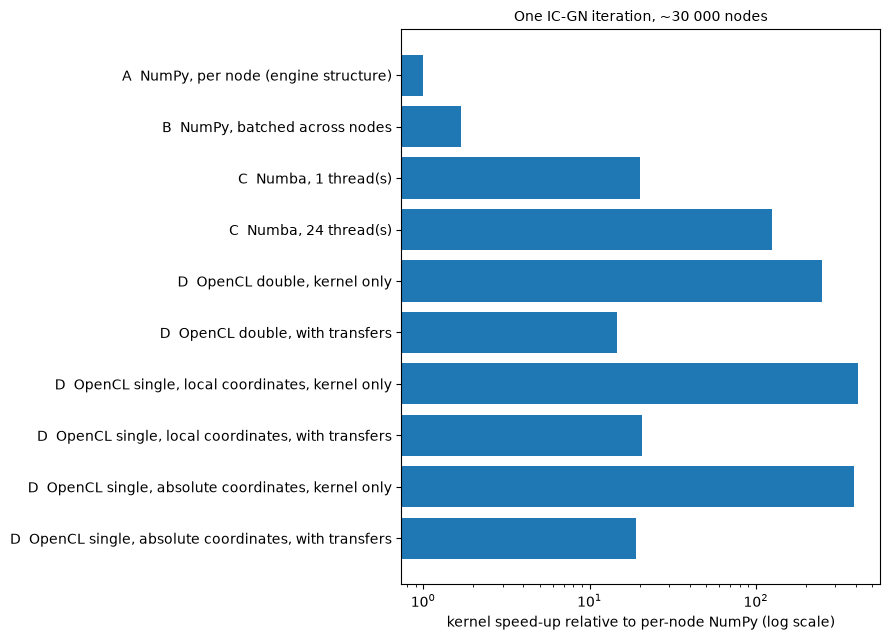

In [9]:
fig, ax = plt.subplots(figsize=(9, 0.5 * len(table) + 1.5))
ax.barh(table.variant, table.speed_up_vs_A, color="tab:blue")
ax.set_xscale("log")
ax.invert_yaxis()
ax.set_xlabel("kernel speed-up relative to per-node NumPy (log scale)")
ax.set_title("One IC-GN iteration, ~30 000 nodes", fontsize=10)
fig.tight_layout()
fig.savefig(RESULTS / "acceleration_kernel.pdf")

## Reading the result

- **Batching (B)** removes the per-node interpreter overhead and is the prerequisite for the GPU; its gain
  over A is the size of that overhead.
- **Numba (C)** removes it by compiling, and with its threads released from the interpreter lock it should
  also scale with the cores, which the engine's threads could not.
- **OpenCL (D)**: the kernel-only time shows the arithmetic capacity of the GPU; the time with transfers
  shows what a port would gain if data were sent per call. A real port would keep the images and the
  reference quantities on the device across iterations and frames, so the attainable gain lies between the two.
- **Precision.** The error of the single-precision variants against the double-precision reference is
  the quantity to compare with the biases of Chapter 5: if local coordinates keep it far below
  $10^{-3}$ pixels while absolute coordinates do not, the design rule for a GPU port is established.
- **Amdahl.** The last columns give the end-to-end result: whatever the kernel speed-up, the whole engine
  cannot gain more than $1/(1-f)$ from accelerating the refinement alone.

In [10]:
table.to_csv(RESULTS / "acceleration_kernel.csv", index=False)
profile.to_csv(RESULTS / "acceleration_profile.csv", index=False)
pd.Series({"numpy": np.__version__, "numba": NUMBA, "opencl": OPENCL, "device": DEVICE,
           "cpu_count": os.cpu_count(), "kernel": platform.release()}).to_csv(
    RESULTS / "acceleration_environment.csv", header=["value"])
for f in ("acceleration_kernel.csv", "acceleration_profile.csv", "acceleration_environment.csv",
          "acceleration_kernel.pdf"):
    print("wrote", RESULTS / f)